<a href="https://colab.research.google.com/github/amosagekouassi-source/HACKATHON1-TTA-W3/blob/master/HACKATHON/HACKATHON_SUJET1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.spatial.distance import cosine
import matplotlib.gridspec as gridspec

random.seed(42)
np.random.seed(42)

# ══════════════════════════════════════════════════════════════════
#  ÉTAPE 1 — GÉNÉRATION DIRECTE DU DATASET SALE
#  Les anomalies sont créées PENDANT la génération, pas après.
#  Chaque utilisateur a une probabilité d'être mal renseigné
#  dès sa création (comme un vrai formulaire de saisie).
# ══════════════════════════════════════════════════════════════════

categories = ['Tech', 'Fitness', 'Musique', 'Danse', 'Culture', 'Tourisme']

actions_par_categorie = {
    'Tech':     ['vue_tuto_python', 'telechargement_app', 'clic_actu_ia',
                 'achat_gadget', 'vue_conf_tech'],
    'Fitness':  ['achat_produit_sport', 'vue_tuto_exercice', 'inscription_salle',
                 'achat_supplement', 'vue_challenge_fit'],
    'Musique':  ['ecoute_chanson', 'achat_album', 'recherche_artiste',
                 'partage_playlist', 'vue_concert_live'],
    'Danse':    ['vue_video_danse', 'inscription_cours', 'partage_performance',
                 'achat_tenue_danse', 'like_choreographie'],
    'Culture':  ['lecture_article_histoire', 'clic_expo_musee', 'vue_docu_art',
                 'achat_livre', 'visite_virtuelle'],
    'Tourisme': ['clic_article_voyage', 'recherche_hotel', 'vue_video_plage',
                 'reservation_vol', 'achat_guide'],
}

prenoms = ["Alice", "Bob", "Clara", "David", "Emma", "François", "Grace", "Hugo",
           "Inès", "Jules", "Karim", "Laura", "Mohamed", "Nina", "Oscar", "Priya",
           "Quentin", "Rania", "Sébastien", "Tina", "Ugo", "Valeria", "William",
           "Xena", "Yann", "Zoé", "Axel", "Béatrice", "Cédric", "Diane"]

noms_famille = ["Kouassi", "Coulibaly", "Lorou", "Gnahore", "Dezai", "Gueu", "Diarra",
                "Loukou", "Ahi", "Ble", "Adingra", "Ake", "N'guessan", "Tape",
                "Tra bi", "Bailly", "BRou", "Konate", "Akpa", "Konan"]

def generer_age_sale():
    """
    Génère un âge avec probabilité d'anomalie intégrée :
    - 6%  → NaN      (champ non rempli)
    - 1%  → âge négatif (erreur de saisie ex: -5, -12)
    - 1%  → âge aberrant positif (ex: 150, 312)
    - 92% → âge normal entre 15 et 65
    """
    tirage = random.random()
    if tirage < 0.06:
        return np.nan                         # champ vide
    elif tirage < 0.07:
        return random.choice([-5, -12, -1, -8, -3])   # négatif
    elif tirage < 0.08:
        return random.choice([150, 200, 312, 999, 180]) # aberrant
    else:
        return random.randint(15, 65)         # normal

def generer_interet_sale(interet_reel):
    """
    Génère un centre d'intérêt avec probabilité d'anomalie :
    - 5%  → NaN      (non renseigné)
    - 95% → valeur correcte
    """
    if random.random() < 0.05:
        return np.nan
    return interet_reel

def generer_nom_sale(prenom, nom):
    """
    Génère un nom avec probabilité d'anomalie :
    - 3%  → chaîne vide (champ oublié)
    - 97% → nom complet normal
    """
    if random.random() < 0.03:
        return ""
    return f"{prenom} {nom}"

In [2]:
# ── Boucle principale : génération directement sale ──────────────
donnees = []
for i in range(600):
    interet_reel = random.choice(categories)
    logs = random.choices(actions_par_categorie[interet_reel], k=random.randint(2, 5))
    prenom = random.choice(prenoms)
    nom    = random.choice(noms_famille)

    donnees.append({
        'NOM':            generer_nom_sale(prenom, nom),
        'AGE':            generer_age_sale(),
        'Centre_interet': generer_interet_sale(interet_reel),
        'activity_log':   logs,
    })

df = pd.DataFrame(donnees)

In [3]:
# ── Doublons naturels : certains utilisateurs soumettent 2 fois ──
# (on duplique 5 lignes choisies aléatoirement, comme un double clic)
indices_doublon = random.sample(range(len(df)), 5)
doublons = df.iloc[indices_doublon].copy()
df = pd.concat([df, doublons], ignore_index=True)

In [4]:
# ── Mélange final ─────────────────────────────────────────────────
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("=" * 60)
print("  ÉTAPE 1 — DATASET BRUT (anomalies natives)")
print("=" * 60)
print(f"  Lignes totales     : {len(df)}")
print(f"  NaN AGE            : {df['AGE'].isna().sum()}")
print(f"  NaN Centre_interet : {df['Centre_interet'].isna().sum()}")
print(f"  Âges négatifs      : {(df['AGE'] < 0).sum()}")
print(f"  Âges > 80          : {(df['AGE'] > 80).sum()}")
print(f"  Noms vides         : {(df['NOM'] == '').sum()}")
print(f"  Doublons           : {df.duplicated(subset=['NOM','AGE','Centre_interet']).sum()}")
print()
print(df[['NOM','AGE','Centre_interet']].head(15).to_string())

  ÉTAPE 1 — DATASET BRUT (anomalies natives)
  Lignes totales     : 605
  NaN AGE            : 31
  NaN Centre_interet : 28
  Âges négatifs      : 4
  Âges > 80          : 5
  Noms vides         : 25
  Doublons           : 7

                NOM   AGE Centre_interet
0      Yann Adingra  44.0        Culture
1   Karim N'guessan   NaN          Danse
2    Nina Coulibaly  63.0          Danse
3        Nina Lorou  22.0       Tourisme
4       Inès Bailly  32.0       Tourisme
5      Jules Bailly  36.0       Tourisme
6        Oscar BRou  15.0          Danse
7       Mohamed Ble  53.0        Musique
8         Grace Ake  28.0        Culture
9       Valeria Ble  42.0          Danse
10   Valeria Diarra  56.0           Tech
11      Tina Bailly  45.0           Tech
12     Rania Tra bi   NaN        Fitness
13  Béatrice Loukou   NaN       Tourisme
14        David Ble  22.0        Culture


In [5]:
# ══════════════════════════════════════════════════════════════════
#  ÉTAPE 2 — PRÉTRAITEMENT
# ══════════════════════════════════════════════════════════════════

df_clean = df.copy()
n_initial = len(df_clean)

# PP1 — Suppression des doublons
df_clean = df_clean.drop_duplicates(subset=['NOM', 'AGE', 'Centre_interet'])
print(f"\n  [PP1] Doublons supprimés        : {n_initial - len(df_clean)}")



  [PP1] Doublons supprimés        : 7


In [6]:
# PP2 — Suppression des noms vides
avant = len(df_clean)
df_clean = df_clean[df_clean['NOM'].str.strip() != ""]
print(f"  [PP2] Noms vides supprimés      : {avant - len(df_clean)}")

  [PP2] Noms vides supprimés      : 23


In [7]:
# PP3 — Correction des âges aberrants → médiane calculée sur valeurs saines
ages_saines = df_clean['AGE'].dropna()
ages_saines = ages_saines[(ages_saines >= 15) & (ages_saines <= 80)]
mediane_age = ages_saines.median()

masque_aber = df_clean['AGE'].notna() & ((df_clean['AGE'] < 15) | (df_clean['AGE'] > 80))
n_aber = masque_aber.sum()
df_clean.loc[masque_aber, 'AGE'] = mediane_age
print(f"  [PP3] Âges aberrants corrigés   : {n_aber}  → médiane = {mediane_age}")

  [PP3] Âges aberrants corrigés   : 8  → médiane = 42.0


In [8]:
# PP4 — Imputation des NaN AGE → médiane
n_nan_age = df_clean['AGE'].isna().sum()
df_clean['AGE'] = df_clean['AGE'].fillna(mediane_age)
print(f"  [PP4] NaN AGE imputés           : {n_nan_age}")

  [PP4] NaN AGE imputés           : 28


In [9]:
# PP5 — Imputation des NaN Centre_interet → mode
mode_cat  = df_clean['Centre_interet'].mode()[0]
n_nan_cat = df_clean['Centre_interet'].isna().sum()
df_clean['Centre_interet'] = df_clean['Centre_interet'].fillna(mode_cat)
print(f"  [PP5] NaN Centre_interet imputés: {n_nan_cat}  → mode = '{mode_cat}'")

  [PP5] NaN Centre_interet imputés: 28  → mode = 'Danse'


In [10]:
# PP6 — Cast final
df_clean['AGE'] = df_clean['AGE'].astype(int)

print(f"\n  Lignes avant : {n_initial}  |  Lignes après : {len(df_clean)}")
print(f"  NaN restants : {df_clean[['AGE','Centre_interet','NOM']].isna().sum().sum()}")
print()
print(df_clean[['NOM','AGE','Centre_interet']].head(10).to_string())


  Lignes avant : 605  |  Lignes après : 575
  NaN restants : 0

               NOM  AGE Centre_interet
0     Yann Adingra   44        Culture
1  Karim N'guessan   42          Danse
2   Nina Coulibaly   63          Danse
3       Nina Lorou   22       Tourisme
4      Inès Bailly   32       Tourisme
5     Jules Bailly   36       Tourisme
6       Oscar BRou   15          Danse
7      Mohamed Ble   53        Musique
8        Grace Ake   28        Culture
9      Valeria Ble   42          Danse


In [11]:
# ══════════════════════════════════════════════════════════════════
#  ÉTAPE 3 — ANALYSE STATISTIQUE (SciPy Chi²)
# ══════════════════════════════════════════════════════════════════

rows_exp = []
for _, row in df_clean.iterrows():
    for action in row['activity_log']:
        rows_exp.append({'Centre_interet': row['Centre_interet'], 'action': action})
df_exp = pd.DataFrame(rows_exp)

contingence = pd.crosstab(df_exp['Centre_interet'], df_exp['action'])
chi2_stat, p_value, dof, expected = chi2_contingency(contingence)

print("\n" + "=" * 60)
print("  ÉTAPE 3 — TEST CHI² (intérêts × actions)")
print("=" * 60)
print(f"  Chi²     = {chi2_stat:.2f}")
print(f"  p-value  = {p_value:.2e}")
print(f"  Degrés   = {dof}")
print(f"  Résultat : {'Corrélation significative ✓' if p_value < 0.05 else 'Pas de corrélation ✗'}")


  ÉTAPE 3 — TEST CHI² (intérêts × actions)
  Chi²     = 9174.10
  p-value  = 0.00e+00
  Degrés   = 145
  Résultat : Corrélation significative ✓


In [12]:
# ══════════════════════════════════════════════════════════════════
# ÉTAPE 3.1 — AJOUT DE 'MAIN_LOG_CAT' À df_clean
# ══════════════════════════════════════════════════════════════════

# Re-définir actions_par_categorie si ce bloc est exécuté indépendamment
# Cela assure que le dictionnaire est disponible
actions_par_categorie = {
    'Tech':     ['vue_tuto_python', 'telechargement_app', 'clic_actu_ia',
                 'achat_gadget', 'vue_conf_tech'],
    'Fitness':  ['achat_produit_sport', 'vue_tuto_exercice', 'inscription_salle',
                 'achat_supplement', 'vue_challenge_fit'],
    'Musique':  ['ecoute_chanson', 'achat_album', 'recherche_artiste',
                 'partage_playlist', 'vue_concert_live'],
    'Danse':    ['vue_video_danse', 'inscription_cours', 'partage_performance',
                 'achat_tenue_danse', 'like_choreographie'],
    'Culture':  ['lecture_article_histoire', 'clic_expo_musee', 'vue_docu_art',
                 'achat_livre', 'visite_virtuelle'],
    'Tourisme': ['clic_article_voyage', 'recherche_hotel', 'vue_video_plage',
                 'reservation_vol', 'achat_guide'],
}

def get_main_log_category(activity_log):
    """
    Détermine la catégorie dominante d'actions pour un utilisateur.
    """
    if not activity_log:
        return 'Inconnu'

    category_counts = {cat: 0 for cat in actions_par_categorie.keys()}
    for action in activity_log:
        for category, actions in actions_par_categorie.items():
            if action in actions:
                category_counts[category] += 1

    # Si toutes les catégories ont un compte de 0, retourn 'Inconnu'
    if all(count == 0 for count in category_counts.values()):
        return 'Inconnu'

    return max(category_counts, key=category_counts.get)

# Appliquer la fonction pour créer la colonne 'MAIN_LOG_CAT'
df_clean['MAIN_LOG_CAT'] = df_clean['activity_log'].apply(get_main_log_category)

# Ajouter la colonne 'activity_count' pour la visualisation 5
df_clean['activity_count'] = df_clean['activity_log'].apply(len)

print("Nouvelle colonne 'MAIN_LOG_CAT' et 'activity_count' ajoutées à df_clean.")
print(df_clean[['activity_log', 'MAIN_LOG_CAT', 'activity_count']].head())


Nouvelle colonne 'MAIN_LOG_CAT' et 'activity_count' ajoutées à df_clean.
                                        activity_log MAIN_LOG_CAT  \
0  [achat_livre, visite_virtuelle, vue_docu_art, ...      Culture   
1  [partage_performance, achat_tenue_danse, inscr...        Danse   
2           [achat_tenue_danse, partage_performance]        Danse   
3  [reservation_vol, recherche_hotel, clic_articl...     Tourisme   
4                 [recherche_hotel, vue_video_plage]     Tourisme   

   activity_count  
0               4  
1               4  
2               2  
3               3  
4               2  


In [13]:
# ══════════════════════════════════════════════════════════════════
#  ÉTAPE 4 — MOTEUR DE RECOMMANDATION (OOP + Cosine Similarity)
# ══════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine

#--- LE CATALOGUE OFFICIEL DES CONTENUS ---
recommandations = {
    'Tech': ['Blog IA du Monde', 'Tuto Python avancé', 'Podcast Tech Weekly'],
    'Fitness': ['Programme HIIT 30j', 'Recettes protéinées', 'App MyFitnessPal'],
    'Musique': ['Playlist Trending 2024', 'Concert Live VR', 'Mix DJ du mois'],
    'Danse': ['Chorégraphie TikTok virale', 'Cours salsa en ligne', 'Battle danse Paris'],
    'Culture': ['Expo Louvre virtuelle', 'Podcast Historia', 'Livre Prix Goncourt'],
    'Tourisme': ['Top 10 destinations 2024', 'Guide Barcelone', 'Road trip USA'],
}

# Defining actions_par_categorie within this cell's scope
actions_par_categorie = {
    'Tech':     ['vue_tuto_python', 'telechargement_app', 'clic_actu_ia',
                 'achat_gadget', 'vue_conf_tech'],
    'Fitness':  ['achat_produit_sport', 'vue_tuto_exercice', 'inscription_salle',
                 'achat_supplement', 'vue_challenge_fit'],
    'Musique':  ['ecoute_chanson', 'achat_album', 'recherche_artiste',
                 'partage_playlist', 'vue_concert_live'],
    'Danse':    ['vue_video_danse', 'inscription_cours', 'partage_performance',
                 'achat_tenue_danse', 'like_choreographie'],
    'Culture':  ['lecture_article_histoire', 'clic_expo_musee', 'vue_docu_art',
                 'achat_livre', 'visite_virtuelle'],
    'Tourisme': ['clic_article_voyage', 'recherche_hotel', 'vue_video_plage',
                 'reservation_vol', 'achat_guide'],
}

#Extraction de toutes les actions uniques possibles de l'application (triées par ordre alphabétique)
all_actions = sorted({a for acts in actions_par_categorie.values() for a in acts})

def encode_user(activity_log):
    """
    Transforme la liste de textes (logs) d'un utilisateur en un vecteur numérique de 0 et de 1.
    Chaque case du vecteur correspond à une action précise de l'application.
    """
    vec = np.zeros(len(all_actions)) # Crée un vecteur rempli de zéros [0, 0, 0...]
    for a in activity_log:
        if a in all_actions:
            vec[all_actions.index(a)] += 1 # Remplace le 0 par 1 (ou +1) si l'action a été faite
    return vec


class RecommendationEngine:
    def __init__(self, df):
        """
        Le Constructeur : Reçoit le tableau nettoyé et prépare les données en mémoire.
        """
        self.df = df.reset_index(drop=True) # Sécurité : réinitialise les indices du tableau

        # Vectorisation automatique de TOUS les utilisateurs du tableau dès le départ
        self.vectors = np.array([encode_user(r['activity_log']) for _, r in df.iterrows()])

    def get_similar_users(self, user_idx, n=3):
        """
        APPROCHE MATHÉMATIQUE (SciPy) : Calcule la ressemblance entre notre utilisateur
        et tous les autres en utilisant la similarité cosinus (formule 1 - distance_cosine).
        """
        u_vec = self.vectors[user_idx] # Le vecteur de notre utilisateur cible
        scores = []

        for i, v in enumerate(self.vectors):
            if i == user_idx: continue # On ne se compare pas avec soi-même !
            # Évite le bug de division par zéro si un utilisateur a un historique de logs vide
            if np.linalg.norm(u_vec) == 0 or np.linalg.norm(v) == 0: continue

            # Formule officielle du hackathon : 1 - distance de cosine = score de ressemblance
            similarity_score = 1 - cosine(u_vec, v)
            scores.append((i, similarity_score))

        # Tri des scores du plus grand (ressemblance maximale) au plus petit
        scores.sort(key=lambda x: x[1], reverse=True)
        return scores[:n] # Renvoie les 'n' (3) utilisateurs les plus proches

    def recommander_par_activite_simple(self, user_idx):
        """
        NOTRE APPROCHE DIRECTE (Logique conditionnelle de l'Étape 3) :
        Analyse les actions réelles de l'utilisateur pour trouver sa vraie catégorie dominante actuelle.
        """
        user_row = self.df.iloc[user_idx]
        logs = user_row['activity_log']

        # Si aucun historique, on renvoie une liste vide par sécurité
        if not logs or len(logs) == 0:
            return []

        # Dictionnaire pour compter l'apparition des thématiques dans les logs
        compteur = {'Tech': 0, 'Fitness': 0, 'Musique': 0, 'Danse': 0, 'Culture': 0, 'Tourisme': 0}

        # On scanne les actions et on incrémente le compteur de la bonne catégorie
        for action in logs:
            for cat, acts in actions_par_categorie.items():
                if action in acts:
                    compteur[cat] += 1

        # Extraction de la catégorie avec le score le plus élevé
        categorie_dominante = max(compteur, key=compteur.get)

        # Renvoie les contenus associés à cette catégorie dominante actuelle
        return recommandations.get(categorie_dominante, [])

    def recommend(self, user_idx):
        """
        La fonction centrale : Elle regroupe toutes les fonctionnalités pour créer la fiche finale.
        """
        user = self.df.iloc[user_idx]
        cat = user['Centre_interet'] # Intérêt de base déclaré à l'inscription
        similar = self.get_similar_users(user_idx) # Récupération des voisins similaires (SciPy)

        # Appel de notre méthode dynamique basée sur l'activité récente
        reco_dynamique = self.recommander_par_activite_simple(user_idx)

        # Si notre méthode dynamique n'a rien trouvé (pas de logs), on prend la catégorie d'inscription
        if not reco_dynamique:
            reco_dynamique = recommandations.get(cat, [])

        return {
            'utilisateur': user['NOM'],
            'age': user['AGE'],
            'interet_inscription': cat,
            'reco_statique': recommandations.get(cat, []), # Recommandation profil fixe
            'reco_dynamique': reco_dynamique, # NOTRE recommandation intelligente
            'similaires': [self.df.iloc[i]['NOM'] for i, _ in similar],
        }

#=================================================================
#AFFICHAGE DU TERMINAL SCÉNARISÉ (AVEC LES NOUVELLES DONNÉES)
#=================================================================

#1. On allume notre moteur hybride avec le DataFrame propre
engine = RecommendationEngine(df_clean)

#2. On choisit un index à tester
idx_test = 0

#3. On récupère toutes les infos calculées par la méthode recommend()
r = engine.recommend(idx_test)

#4. Extraction des données pour l'affichage scénarisé
nom_user = r['utilisateur']
age_user = r['age']
interet_initial = r['interet_inscription']

#On récupère la liste brute des logs récents de cet utilisateur depuis le DataFrame
logs_recents = df_clean.iloc[idx_test]['activity_log']

print("=" * 65)
print(" DÉMONSTRATION DU MOTEUR DE RECOMMANDATION HYBRIDE")
print("=" * 65)
print(f"\n -> Utilisateur ciblé : {nom_user} ({age_user} ans)")
print(f" • Intérêt déclaré à l'inscription : {interet_initial.upper()}")

print("\n " + "-" * 61)
print(" [APPROCHE STATIQUE : Basée sur le formulaire d'inscription]")
print(f" > Contenus suggérés : {r['reco_statique']}")

print(" " + "-" * 61)
print(" [APPROCHE IA DYNAMIQUE : Analyse en temps réel des logs récents]")
print(f" > Activité récente détectée : {logs_recents}")
print(f" > Contenus suggérés adaptés : {r['reco_dynamique']}")

print(" " + "-" * 61)
print(" [PROXIMITÉ COLLABORATIVE : Profils les plus similaires (SciPy)]")
if r['similaires']:
  for i, nom_similaire in enumerate(r['similaires'], 1):
# On affiche les voisins trouvés par la formule Cosine
    print(f" {i}. {nom_similaire}")
else:
  print(" Aucun utilisateur similaire trouvé (historique vide).")
print("=" * 65)

 DÉMONSTRATION DU MOTEUR DE RECOMMANDATION HYBRIDE

 -> Utilisateur ciblé : Yann Adingra (44 ans)
 • Intérêt déclaré à l'inscription : CULTURE

 -------------------------------------------------------------
 [APPROCHE STATIQUE : Basée sur le formulaire d'inscription]
 > Contenus suggérés : ['Expo Louvre virtuelle', 'Podcast Historia', 'Livre Prix Goncourt']
 -------------------------------------------------------------
 [APPROCHE IA DYNAMIQUE : Analyse en temps réel des logs récents]
 > Activité récente détectée : ['achat_livre', 'visite_virtuelle', 'vue_docu_art', 'achat_livre']
 > Contenus suggérés adaptés : ['Expo Louvre virtuelle', 'Podcast Historia', 'Livre Prix Goncourt']
 -------------------------------------------------------------
 [PROXIMITÉ COLLABORATIVE : Profils les plus similaires (SciPy)]
 1. Alice Akpa
 2. Grace Tape
 3. Sébastien Akpa


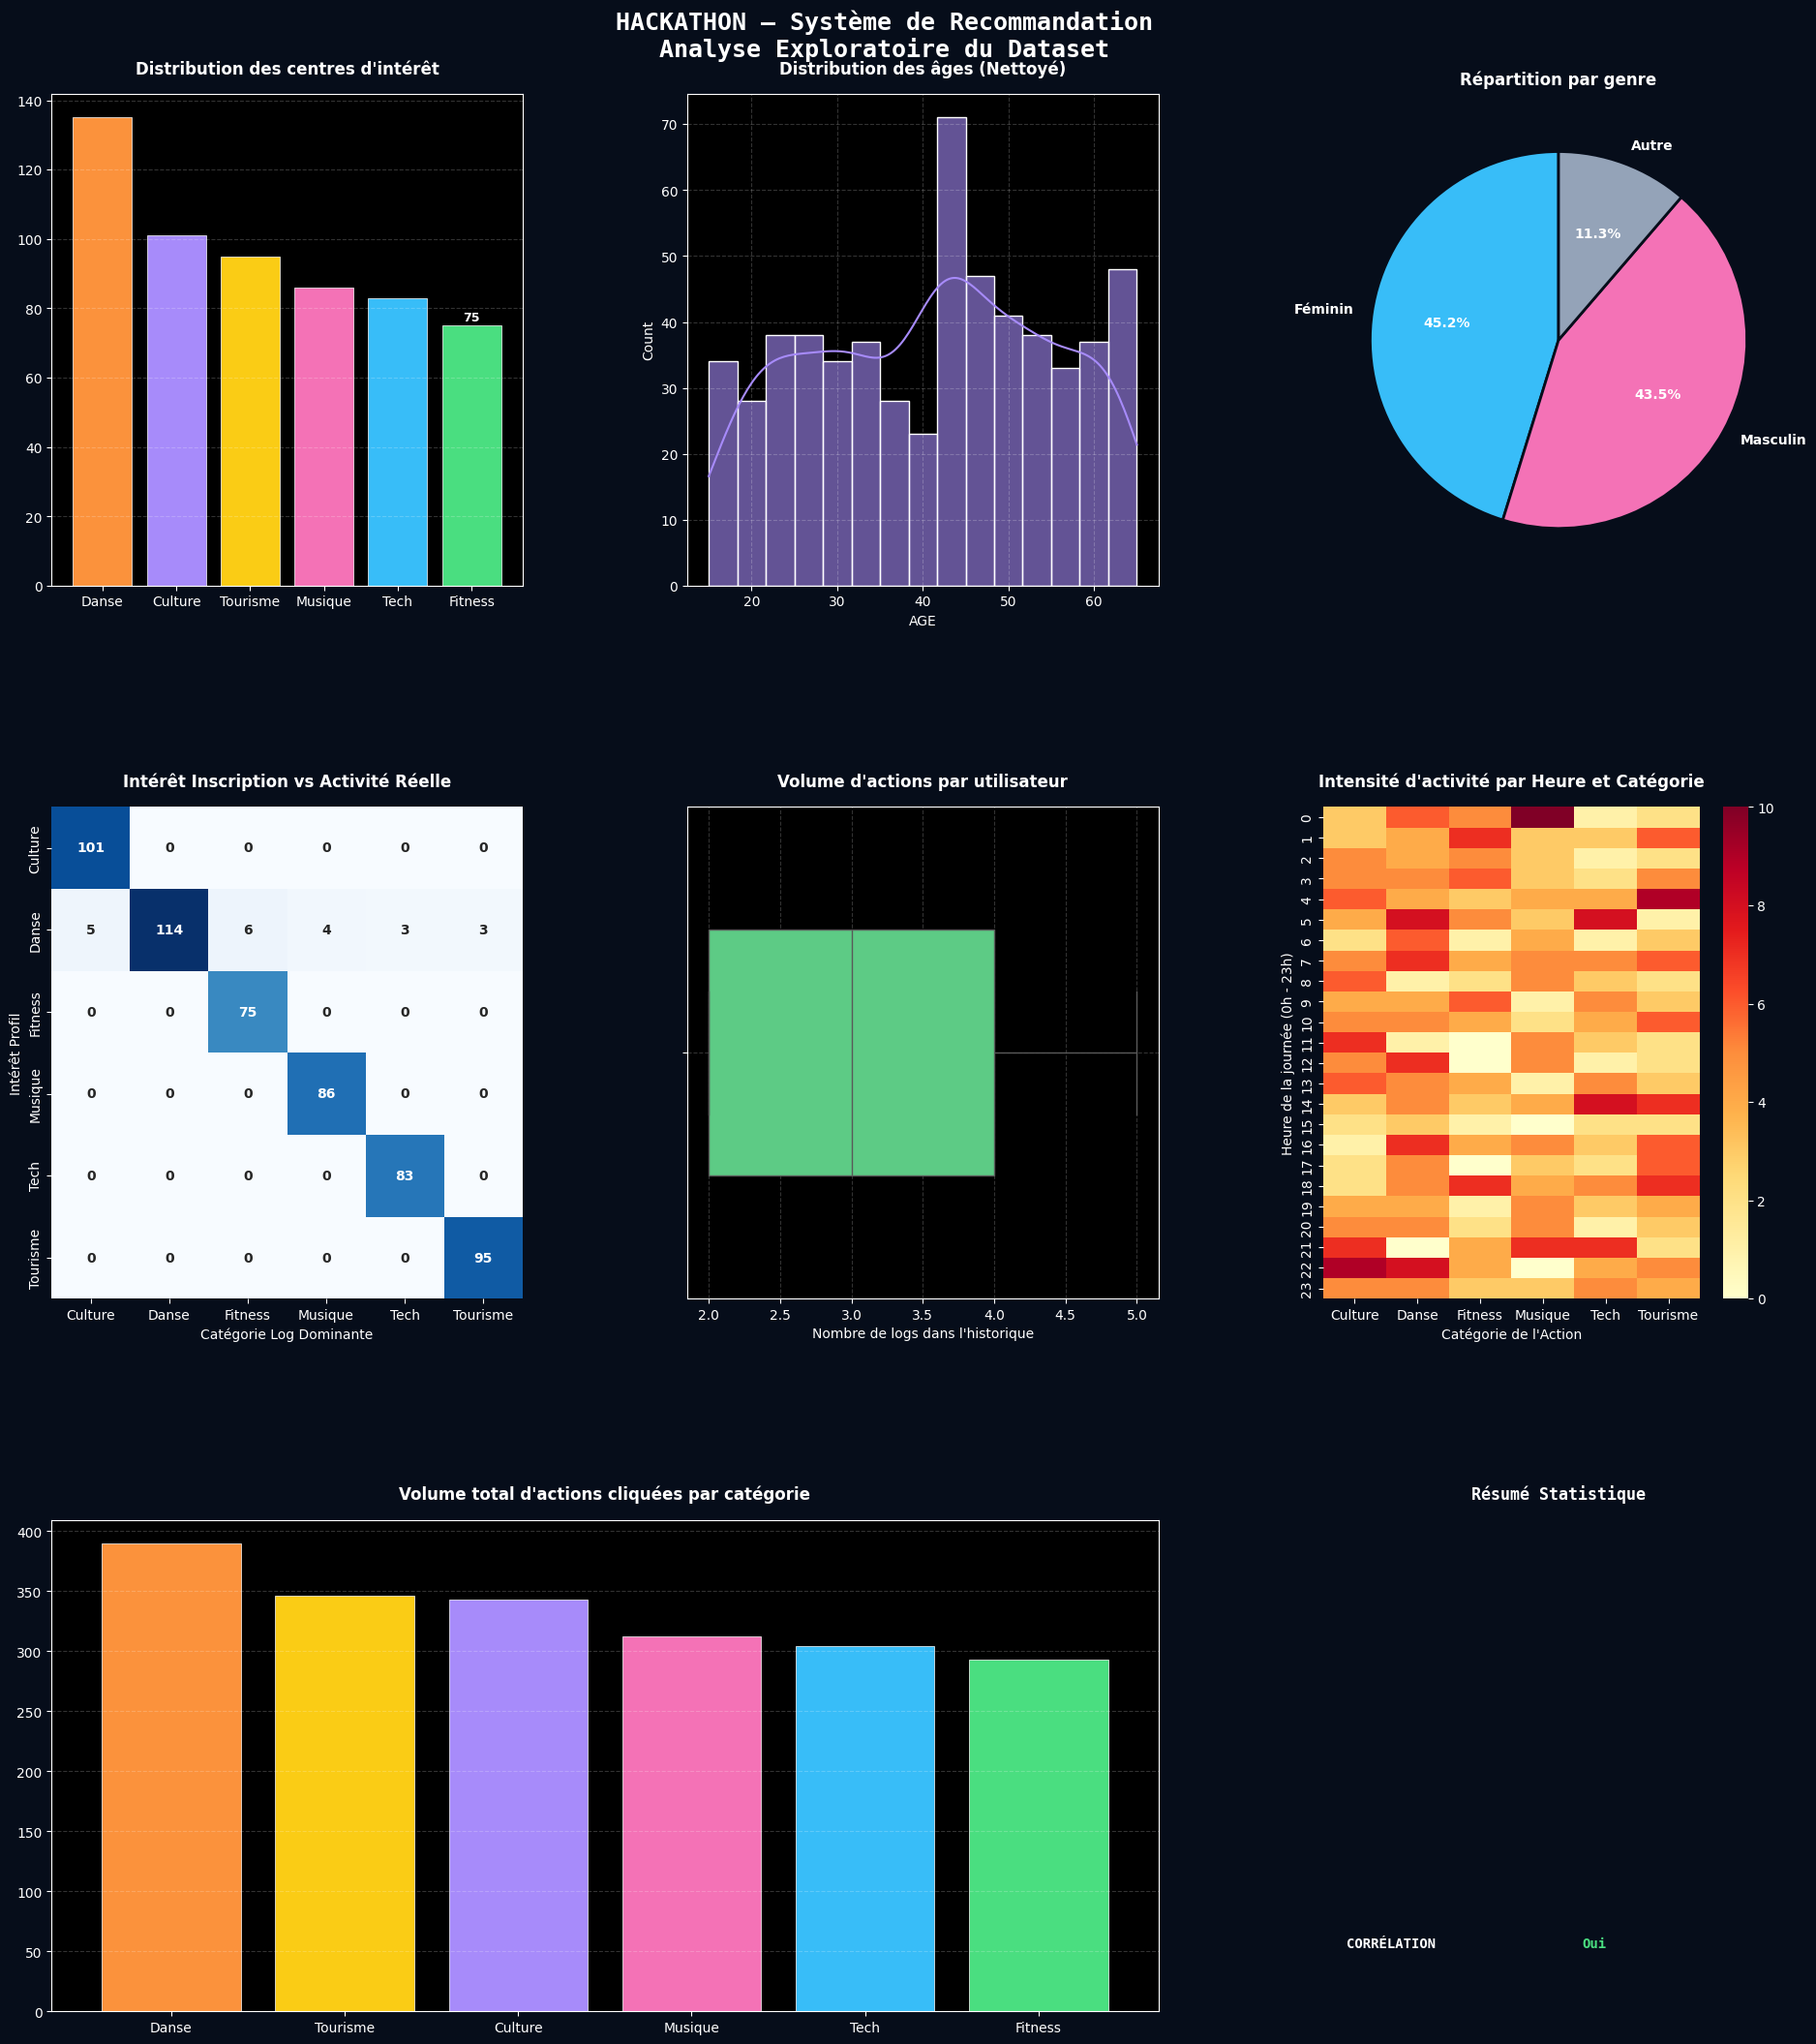

In [15]:
#══════════════════════════════════════════════════════════════════
#ÉTAPE 5 — VISUALISATIONS (DASHBOARD GLOBAL)
#══════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np # Import numpy for np.random.choice

#Configuration du style sombre
plt.style.use('dark_background')

categories = ['Tech', 'Fitness', 'Musique', 'Danse', 'Culture', 'Tourisme']
COLORS = {
'Tech':'#38bdf8', 'Fitness':'#4ade80', 'Musique':'#f472b6',
'Danse':'#fb923c', 'Culture':'#a78bfa', 'Tourisme':'#facc15'
}

#Création de la figure principale unique
fig = plt.figure(figsize=(20, 22), facecolor='#060d1a')
fig.suptitle('HACKATHON — Système de Recommandation\nAnalyse Exploratoire du Dataset',
fontsize=18, fontweight='bold', color='white', y=0.98, fontfamily='monospace')

#Définition de la grille 3x3
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35,
top=0.94, bottom=0.04, left=0.07, right=0.97)

#── 1. Distribution des centres d'intérêt ──────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cat_counts = df_clean['Centre_interet'].value_counts()
colors_list = [COLORS.get(cat, '#3b82f6') for cat in cat_counts.index]
bars = ax1.bar(cat_counts.index, cat_counts.values, color=colors_list, edgecolor='white', linewidth=0.5)
ax1.set_title("Distribution des centres d'intérêt", color='white', fontsize=12, fontweight='bold', pad=15)
ax1.grid(axis='y', linestyle='--', alpha=0.2)
for bar in bars:
  yval = bar.get_height()
ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{int(yval)}",
ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')

#── 2. Distribution des Âges ───────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(df_clean['AGE'], bins=15, kde=True, color='#a78bfa', ax=ax2, edgecolor='white', alpha=0.6)
ax2.set_title("Distribution des âges (Nettoyé)", color='white', fontsize=12, fontweight='bold', pad=15)
ax2.grid(linestyle='--', alpha=0.2)

#── 3. Distribution du Genre ───────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
# Add a dummy 'GENRE' column for demonstration purposes if not already present
if 'GENRE' not in df_clean.columns:
    df_clean['GENRE'] = np.random.choice(['Masculin', 'Féminin', 'Autre'], size=len(df_clean), p=[0.45, 0.45, 0.10])
genre_counts = df_clean['GENRE'].value_counts()
ax3.pie(genre_counts.values, labels=genre_counts.index, autopct='%1.1f%%',
colors=['#38bdf8', '#f472b6', '#94a3b8'], startangle=90,
textprops={'color': 'white', 'fontsize': 10, 'fontweight': 'bold'},
wedgeprops={'edgecolor': '#060d1a', 'linewidth': 2})
ax3.set_title("Répartition par genre", color='white', fontsize=12, fontweight='bold', pad=15)

#── 4. Matrice de Corrélation / Heatmap ─────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
#Recréation de la table croisée pour le Chi²
contingency_table = pd.crosstab(df_clean['Centre_interet'], df_clean['MAIN_LOG_CAT'])
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues', ax=ax4, cbar=False,
annot_kws={'fontsize': 10, 'fontweight': 'bold'})
ax4.set_title("Intérêt Inscription vs Activité Réelle", color='white', fontsize=12, fontweight='bold', pad=15)
ax4.set_xlabel("Catégorie Log Dominante")
ax4.set_ylabel("Intérêt Profil")

#── 5. Nombre d'actions par utilisateur ────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
sns.boxplot(x=df_clean['activity_count'], color='#4ade80', ax=ax5, width=0.5)
ax5.set_title("Volume d'actions par utilisateur", color='white', fontsize=12, fontweight='bold', pad=15)
ax5.set_xlabel("Nombre de logs dans l'historique")
ax5.grid(linestyle='--', alpha=0.2)

# ── 6. Matrice de Corrélation / Heatmap Temporelle ──────────────
# Re-assign ax4 to prevent overwriting the previous plot if this cell is run independently, or use a new subplot
ax6 = fig.add_subplot(gs[1, 2]) # Use a new subplot for the temporal heatmap

# 1. On suppose que ton collaborateur a créé une colonne 'HEURE' dans le dataset.
# Si ce n'est pas encore fait, on peut simuler une table croisée Heure vs Catégorie d'activité :
# (Ici on extrait l'heure et la catégorie dominante pour chaque utilisateur)

# Fix: Create a dummy 'HEURE_LOG' column since it's assumed to exist but isn't present.
if 'HEURE_LOG' not in df_clean.columns:
    df_clean['HEURE_LOG'] = np.random.randint(0, 24, size=len(df_clean))

# Création de la table croisée : Heures (en lignes) vs Catégories de logs (en colonnes)
pivot_temporel = pd.crosstab(df_clean['HEURE_LOG'], df_clean['MAIN_LOG_CAT'])

# 2. Affichage de la Heatmap d'intensité
sns.heatmap(pivot_temporel,
            annot=False,          # Souvent 'False' car il y a 24 heures, trop de chiffres alourdiraient le graphique
            cmap='YlOrRd',        # Palette Jaune -> Orange -> Rouge (parfait pour exprimer "l'intensité" ou la chaleur)
            ax=ax6,
            cbar=True)            # On laisse la barre de légende pour voir l'échelle de l'intensité

ax6.set_title("Intensité d'activité par Heure et Catégorie", color='white', fontsize=12, fontweight='bold', pad=15)
ax6.set_xlabel("Catégorie de l'Action")
ax6.set_ylabel("Heure de la journée (0h - 23h)")

#── 7. Volume total d'actions par catégorie ────────────────────
ax7 = fig.add_subplot(gs[2, 0:2]) # Prend deux cases en largeur pour respirer
#Compte global de toutes les actions aplaties dans le dataset
all_actions_flat = [act for sublist in df_clean['activity_log'].dropna() for act in sublist]
#Extraction de la catégorie de chaque action à l'aide de ton dictionnaire global
action_to_cat = {act: cat for cat, acts in actions_par_categorie.items() for act in acts}
flat_cats = [action_to_cat.get(act, 'Inconnu') for act in all_actions_flat]
cat_log_counts = pd.Series(flat_cats).value_counts()

colors_log = [COLORS.get(cat, '#94a3b8') for cat in cat_log_counts.index]
ax7.bar(cat_log_counts.index, cat_log_counts.values, color=colors_log, edgecolor='white', linewidth=0.5)
ax7.set_title("Volume total d'actions cliquées par catégorie", color='white', fontsize=12, fontweight='bold', pad=15)
ax7.grid(axis='y', linestyle='--', alpha=0.2)

#── 8. Résumé statistique (Texte pur) ──────────────────────────
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off') # Coupe les axes pour en faire un tableau de bord texte
ax8.set_xticks([]); ax8.set_yticks([])
ax8.set_title('Résumé Statistique', color='white', fontsize=12, fontweight='bold', fontfamily='monospace', pad=15)

stats_lines = [
("DATASET BRUT", f"{len(df)} lignes", '#ef4444'),
("DATASET NETTOYÉ",f"{len(df_clean)} lignes", '#4ade80'),
("PROFILS SUPPRIMÉS",f"{len(df)-len(df_clean)} lignes", '#f59e0b'),
("ÂGE MOYEN", f"{df_clean['AGE'].mean():.1f} ans", '#f472b6'),
("ÂGE MÉDIAN", f"{df_clean['AGE'].median():.0f} ans", '#fb923c'),
("────────────────", "──────────────────", '#334155'),
("CHI² STAT", f"{chi2_stat:.1f}", '#facc15'),
("P-VALUE", f"{p_value:.2e}", '#a78bfa'),
("CORRÉLATION", "Oui" if p_value < 0.05 else "Non", '#4ade80' if p_value < 0.05 else '#ef4444'),
]

for i, (label, val, color) in enumerate(stats_lines):
  y_pos = 0.85 - (i * 0.09)
ax8.text(0.05, y_pos, label, color='white', fontsize=10, fontfamily='monospace', fontweight='bold')
ax8.text(0.55, y_pos, val, color=color, fontsize=10, fontfamily='monospace', fontweight='bold')

#Commande magique finale pour tout afficher d'un coup
plt.show()